# ML-06 — Signal Audit: Do the Flags Hold?

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
%pip -q install duckdb huggingface_hub

In [2]:
import os
import getpass
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display

# HF authentication
HF_TOKEN = os.environ.get("HF_TOKEN") or getpass.getpass(
    "Paste your Hugging Face READ token (hf_...): "
)

# DuckDB connection
con = duckdb.connect()

con.execute(
    f"CREATE OR REPLACE SECRET hf "
    f"(TYPE huggingface, TOKEN '{HF_TOKEN}')"
)

REL = "hf://datasets/FlyRank/internship-warehouse"

TABLES = {
    "dim_clients":
        f"read_parquet('{REL}/dim_clients.parquet')",

    "dim_content":
        f"read_parquet('{REL}/dim_content.parquet')",

    "fact_daily":
        f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",

    "fact_daily_sample":
        f"read_parquet('{REL}/fact_content_daily_performance_sample.parquet')",

    "fact_query_90d":
        f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

for name, src in TABLES.items():
    n = con.sql(f"SELECT COUNT(*) FROM {src}").fetchone()[0]
    print(f"{name:22} {n:>12,} rows")

Paste your Hugging Face READ token (hf_...): ··········
dim_clients                     104 rows
dim_content                 519,606 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

fact_daily               78,835,655 rows
fact_daily_sample        11,694,072 rows
fact_query_90d            2,414,248 rows


In [3]:
FEATURE_START = "2026-03-01"
FEATURE_END   = "2026-04-01"

TARGET_START = "2026-04-01"
TARGET_END   = "2026-05-01"

print("Feature window:", FEATURE_START, "to", FEATURE_END)
print("Target window: ", TARGET_START, "to", TARGET_END)

Feature window: 2026-03-01 to 2026-04-01
Target window:  2026-04-01 to 2026-05-01


```text
March 2026
     │
     │ historical information
     ▼
2026-04-01  ← prediction moment
     │
     │ future outcome
     ▼
April 2026
```
The signal audit should primarily examine signals available by **2026-04-01**.

In [4]:
feature_data = con.sql(f"""
    WITH march AS (

        SELECT
            client_hash_id,
            content_hash_id,

            SUM(
                CASE
                    WHEN gsc_data_available IS TRUE
                    THEN gsc_impressions
                    ELSE 0
                END
            ) AS imp_prev30,

            SUM(
                CASE
                    WHEN gsc_data_available IS TRUE
                    THEN gsc_clicks
                    ELSE 0
                END
            ) AS clk_prev30,

            SUM(
                CASE
                    WHEN gsc_data_available IS TRUE
                    THEN gsc_impressions
                    ELSE 0
                END
            ) AS impressions,

            AVG(
                CASE
                    WHEN gsc_data_available IS TRUE
                    THEN gsc_avg_position
                END
            ) AS avg_position_prev30,

            COUNT(
                CASE
                    WHEN gsc_data_available IS TRUE
                         AND gsc_impressions > 0
                    THEN 1
                END
            ) AS days_with_impressions

        FROM {TABLES["fact_daily"]}

        WHERE report_date >= DATE '{FEATURE_START}'
          AND report_date < DATE '{FEATURE_END}'

        GROUP BY
            client_hash_id,
            content_hash_id
    )

    SELECT
        m.client_hash_id,
        m.content_hash_id,

        m.imp_prev30,
        m.clk_prev30,
        m.avg_position_prev30,
        m.days_with_impressions,

        c.content_created_date,
        c.content_updated_date,
        c.content_type,
        c.main_intent,
        c.word_count,
        c.char_count,
        c.search_volume,
        c.competition,
        c.cpc,
        c.backlinks,
        c.category_count,

        DATE_DIFF(
            'day',
            c.content_created_date,
            DATE '{TARGET_START}'
        ) AS content_age_days,

        DATE_DIFF(
            'day',
            c.content_updated_date,
            DATE '{TARGET_START}'
        ) AS days_since_update

    FROM march m

    LEFT JOIN {TABLES["dim_content"]} c
        ON m.client_hash_id = c.client_hash_id
        AND m.content_hash_id = c.content_hash_id

    WHERE m.imp_prev30 >= 100
""").df()

print("Rows:", len(feature_data))
print("Columns:", len(feature_data.columns))

display(feature_data.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 101441
Columns: 19


,client_hash_id,content_hash_id,imp_prev30,clk_prev30,avg_position_prev30,days_with_impressions,content_created_date,content_updated_date,content_type,main_intent,word_count,char_count,search_volume,competition,cpc,backlinks,category_count,content_age_days,days_since_update
0,client_0797ff3a1fc9a6a5,content_04c67f3541177192,331.0,2.0,14.129210,31,2025-10-07,2026-02-25,keyword article,informational,3168,19446,0,0.0,0.00,0,0,176,35
1,client_0797ff3a1fc9a6a5,content_0f30e04e709c7b5d,145.0,0.0,8.470926,30,2025-10-07,2026-02-25,keyword article,informational,3211,19567,0,0.0,0.00,0,0,176,35
2,client_0797ff3a1fc9a6a5,content_1207efddce873942,461.0,0.0,14.859827,31,2025-10-07,2026-05-20,keyword article,informational,3465,21900,0,0.0,0.00,0,0,176,-49
3,client_0797ff3a1fc9a6a5,content_167472cd0802a8f3,232.0,0.0,12.297523,29,2025-10-07,2026-02-25,keyword article,informational,3149,19879,0,0.0,0.00,0,0,176,35
4,client_0797ff3a1fc9a6a5,content_27f8100281413b37,464.0,0.0,9.554793,18,2025-10-07,2026-02-25,keyword article,transactional,4016,25067,20,1.0,0.94,0,2,176,35


In [5]:
future_data = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(gsc_impressions) AS imp_next30,
        SUM(gsc_clicks) AS clk_next30,

        AVG(gsc_avg_position) AS avg_position_next30

    FROM {TABLES["fact_daily"]}

    WHERE report_date >= DATE '{TARGET_START}'
      AND report_date < DATE '{TARGET_END}'

      AND gsc_data_available IS TRUE

    GROUP BY
        client_hash_id,
        content_hash_id
""").df()

print("Future outcome rows:", len(future_data))

display(future_data.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Future outcome rows: 194760


,client_hash_id,content_hash_id,imp_next30,clk_next30,avg_position_next30
0,client_62f4a7e64f5e0096,content_76c1f31e2b38f054,249.0,1.0,24.355101
1,client_62f4a7e64f5e0096,content_ffc5ab4b34aab1f8,281.0,0.0,19.025035
2,client_62f4a7e64f5e0096,content_9739856fc83dc1ca,722.0,0.0,21.446992
3,client_62f4a7e64f5e0096,content_3d1dc691a3502105,3068.0,1.0,13.363941
4,client_62f4a7e64f5e0096,content_9d28af4f99c5e67b,3896.0,3.0,9.190009


In [6]:
audit = feature_data.merge(
    future_data,
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

print("Audit rows:", len(audit))

Audit rows: 100893


In [7]:
audit["impression_change_pct"] = (
    (audit["imp_next30"] - audit["imp_prev30"])
    / audit["imp_prev30"]
)

audit["is_declining"] = (
    audit["impression_change_pct"] < -0.20
).astype(int)

print(
    audit["is_declining"]
    .value_counts()
    .rename({
        0: "not_declining",
        1: "declining"
    })
)

print(
    "\nDecline rate:",
    round(audit["is_declining"].mean(), 3)
)

is_declining
declining        51944
not_declining    48949
Name: count, dtype: int64

Decline rate: 0.515


In [8]:
audit_features = [
    "imp_prev30",
    "clk_prev30",
    "avg_position_prev30",
    "days_with_impressions",
    "content_age_days",
    "days_since_update",
    "word_count",
    "char_count",
    "search_volume",
    "competition",
    "cpc",
    "backlinks",
    "category_count",
]

missing_check = pd.DataFrame({
    "column": audit_features,
    "n": [
        audit[c].notna().sum()
        for c in audit_features
    ],
    "missing": [
        audit[c].isna().sum()
        for c in audit_features
    ],
})

missing_check["missing_pct"] = (
    missing_check["missing"] /
    len(audit) *
    100
).round(2)

display(
    missing_check.sort_values(
        "missing_pct",
        ascending=False
    )
)

,column,n,missing,missing_pct
11,backlinks,63805,37088,36.76
6,word_count,72031,28862,28.61
7,char_count,72031,28862,28.61
8,search_volume,99096,1797,1.78
10,cpc,99096,1797,1.78
9,competition,99096,1797,1.78
4,content_age_days,100893,0,0.00
2,avg_position_prev30,100893,0,0.00
1,clk_prev30,100893,0,0.00
0,imp_prev30,100893,0,0.00


## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

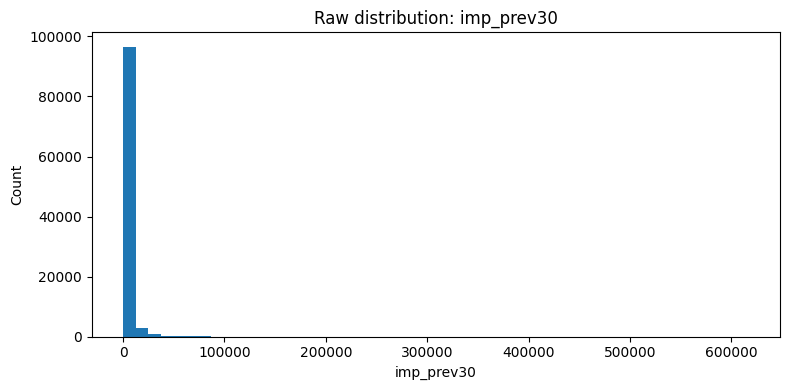

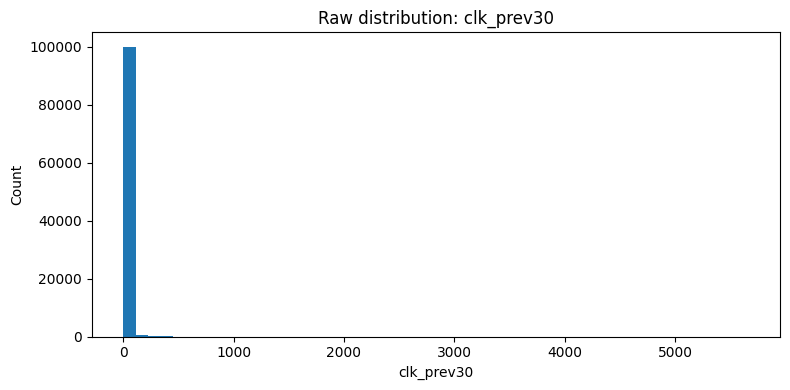

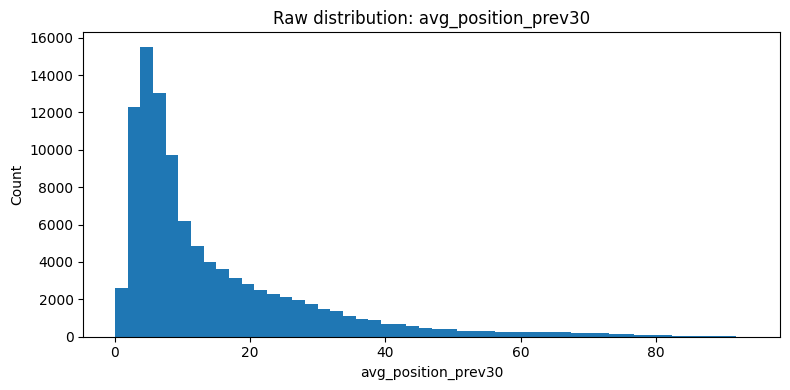

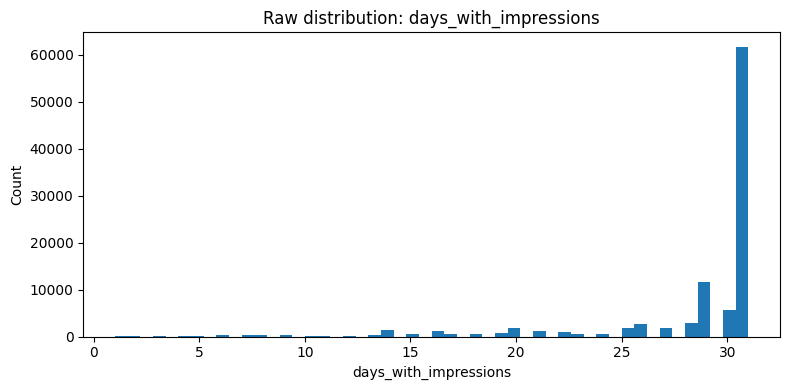

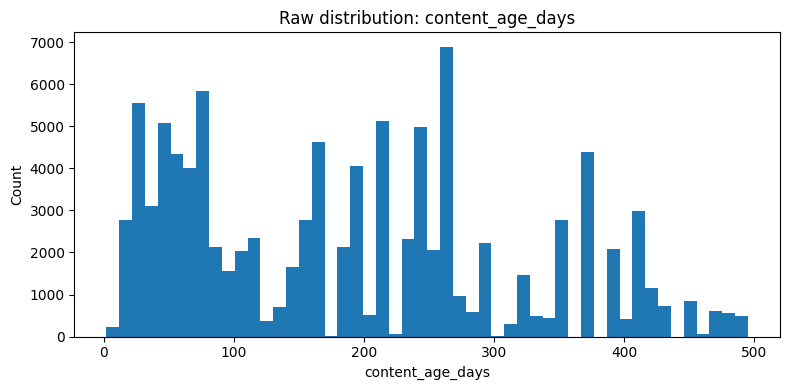

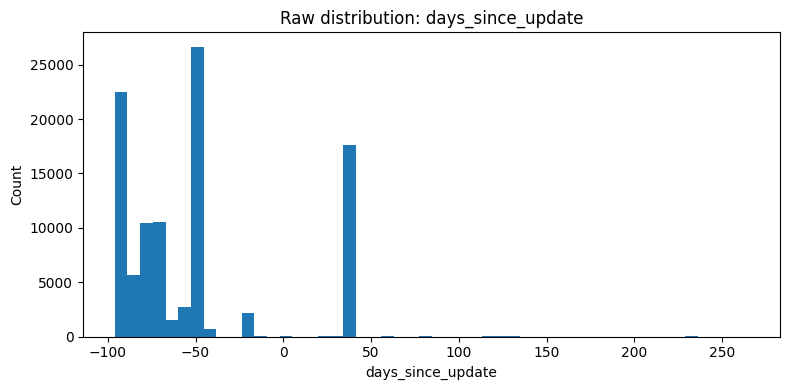

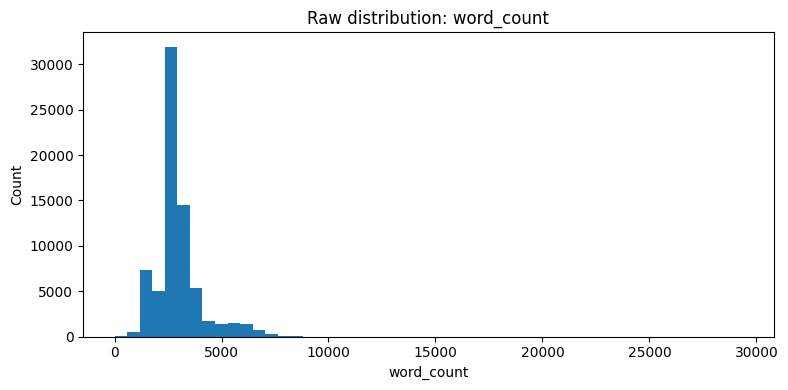

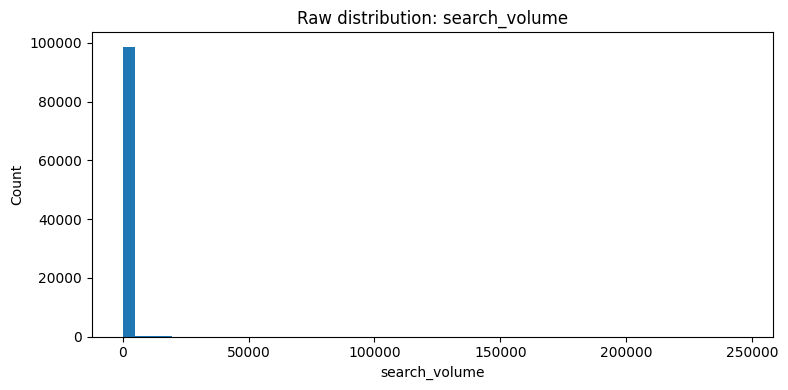

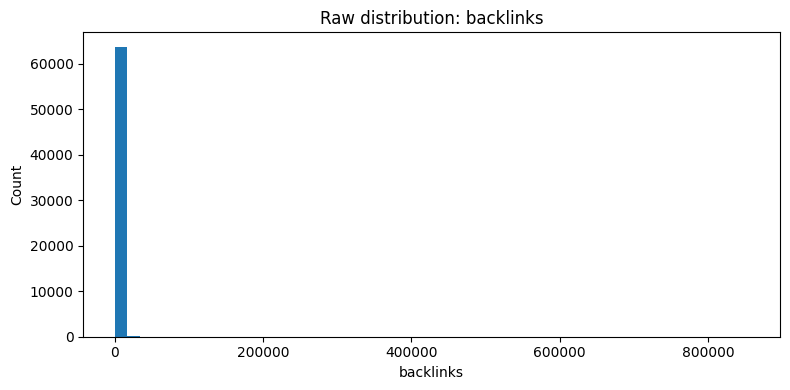

In [9]:
distribution_cols = [
    "imp_prev30",
    "clk_prev30",
    "avg_position_prev30",
    "days_with_impressions",
    "content_age_days",
    "days_since_update",
    "word_count",
    "search_volume",
    "backlinks",
]

for col in distribution_cols:

    plt.figure(figsize=(8, 4))

    audit[col].dropna().plot(
        kind="hist",
        bins=50
    )

    plt.title(f"Raw distribution: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.tight_layout()
    plt.show()

In [10]:
audit["log_imp_prev30"] = np.log1p(audit["imp_prev30"])
audit["log_clk_prev30"] = np.log1p(audit["clk_prev30"])
audit["log_search_volume"] = np.log1p(audit["search_volume"].clip(lower=0))
audit["log_backlinks"] = np.log1p(audit["backlinks"].clip(lower=0))

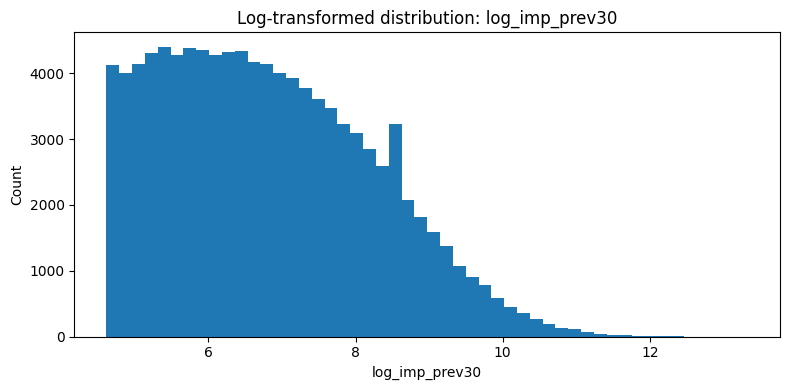

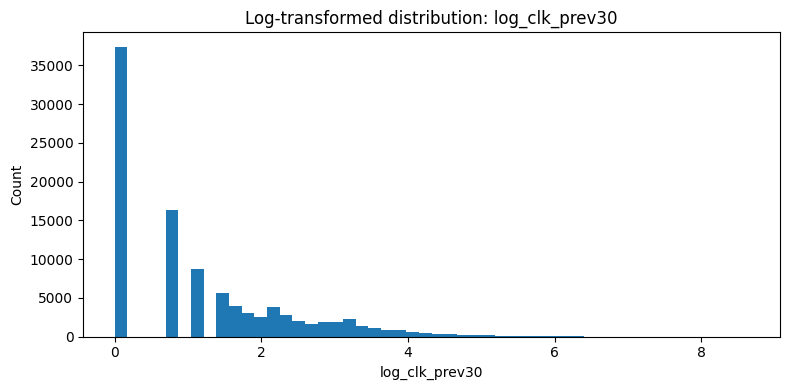

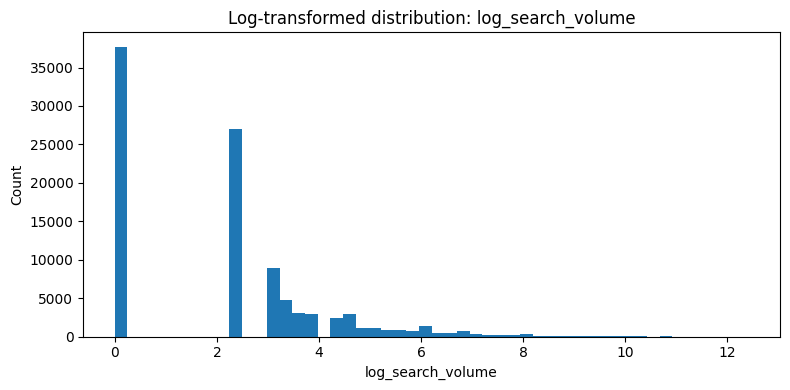

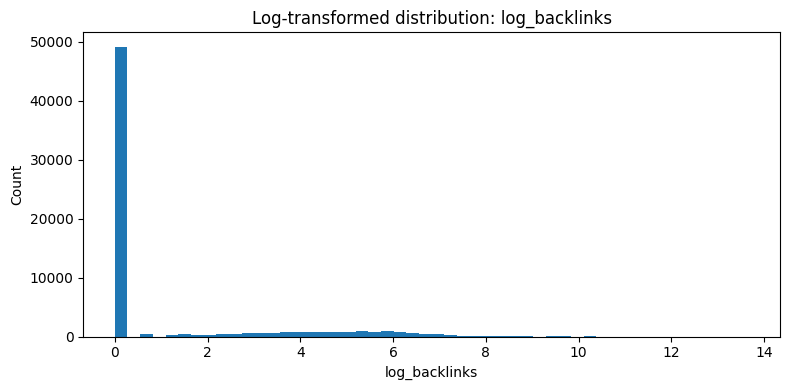

In [11]:
log_cols = [
    "log_imp_prev30",
    "log_clk_prev30",
    "log_search_volume",
    "log_backlinks",
]

for col in log_cols:

    plt.figure(figsize=(8, 4))

    audit[col].dropna().plot(
        kind="hist",
        bins=50
    )

    plt.title(f"Log-transformed distribution: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.tight_layout()
    plt.show()

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

### Signal Test 1 - Historical Visibility

In [12]:
audit["visibility_bucket"] = pd.qcut(
    audit["imp_prev30"],
    q=5,
    duplicates="drop"
)

visibility_test = (
    audit
    .groupby("visibility_bucket", observed=True)
    .agg(
        n=("is_declining", "size"),
        median_impressions=("imp_prev30", "median"),
        mean_impressions=("imp_prev30", "mean"),
        decline_rate=("is_declining", "mean")
    )
    .reset_index()
)

visibility_test["decline_rate"] = (visibility_test["decline_rate"] * 100).round(2)

display(visibility_test)

,visibility_bucket,n,median_impressions,mean_impressions,decline_rate
0,"(99.999, 233.0]",20249,155.0,158.647094,53.46
1,"(233.0, 525.0]",20118,350.0,360.279004,54.39
2,"(525.0, 1225.0]",20184,795.0,820.999306,53.07
3,"(1225.0, 3369.0]",20165,1961.0,2068.177684,50.97
4,"(3369.0, 617124.0]",20177,6445.0,10400.929078,45.53


In [31]:
MIN_N = 50

if (visibility_test["n"] < MIN_N).any():

    print("VERDICT: INSUFFICIENT DATA")
    print("At least one bucket has fewer than 50 observations.")

else:

    # --------------------------------------------------------
    # 4. Compare lowest and highest visibility buckets
    # --------------------------------------------------------

    low_rate = visibility_test.iloc[0]["decline_rate"]
    high_rate = visibility_test.iloc[-1]["decline_rate"]

    print(
        f"Lowest visibility decline rate:  {low_rate:.2f}%"
    )

    print(
        f"Highest visibility decline rate: {high_rate:.2f}%"
    )

    print(
        f"Difference: {high_rate - low_rate:.2f} percentage points"
    )

    # --------------------------------------------------------
    # 5. Check whether the pattern is monotonic
    # --------------------------------------------------------

    rates = visibility_test["decline_rate"].to_numpy()

    differences = np.diff(rates)

    print("\nChanges between consecutive buckets:")
    print(differences)

    if np.all(differences < 0):

        verdict = "CONFIRMED"

        explanation = (
            "Higher historical visibility is associated with "
            "a lower observed future decline rate."
        )

    elif np.all(differences > 0):

        verdict = "OPPOSITE"

        explanation = (
            "Higher historical visibility is associated with "
            "a higher observed future decline rate."
        )

    else:

        verdict = "MIXED"

        explanation = (
            "Decline rates do not move consistently across "
            "historical-visibility buckets."
        )

    print("\nVERDICT:", verdict)
    print(explanation)

Lowest visibility decline rate:  53.46%
Highest visibility decline rate: 45.53%
Difference: -7.93 percentage points

Changes between consecutive buckets:
[ 0.93 -1.32 -2.1  -5.44]

VERDICT: MIXED
Decline rates do not move consistently across historical-visibility buckets.


In [32]:
# Find clients with the most observations
client_counts = (
    audit
    .groupby("client_hash_id")
    .size()
    .sort_values(ascending=False)
)

SECOND_SLICE_CLIENT = client_counts.index[0]

second_slice = audit[
    audit["client_hash_id"] == SECOND_SLICE_CLIENT
].copy()

print("Second-slice client:", SECOND_SLICE_CLIENT)
print("Rows:", len(second_slice))

# ------------------------------------------------------------
# Create buckets and repeat the test
# ------------------------------------------------------------

if len(second_slice) >= 50:

    second_slice["visibility_bucket"] = pd.qcut(
        second_slice["imp_prev30"],
        q=5,
        duplicates="drop"
    )

    visibility_second = (
        second_slice
        .groupby(
            "visibility_bucket",
            observed=True
        )
        .agg(
            n=("is_declining", "size"),
            median_impressions=("imp_prev30", "median"),
            decline_rate=("is_declining", "mean")
        )
        .reset_index()
    )

    visibility_second["decline_rate"] = (
        visibility_second["decline_rate"] * 100
    ).round(2)

    visibility_second = visibility_second.sort_values(
        "median_impressions"
    )

    display(visibility_second)

else:

    print(
        "Insufficient rows for second-slice audit."
    )

Second-slice client: client_73cda7b4e4f265ea
Rows: 21620


,visibility_bucket,n,median_impressions,decline_rate
0,"(99.999, 269.0]",4330,168.0,40.00
1,"(269.0, 635.0]",4320,417.0,45.83
2,"(635.0, 1525.0]",4326,976.0,48.01
3,"(1525.0, 4044.0]",4321,2418.0,44.46
4,"(4044.0, 164885.0]",4323,8246.0,37.01


### Signal test 2 — Content staleness

In [18]:
audit["staleness_bucket"] = pd.cut(
    audit["days_since_update"],
    bins=[
        -1,
        30,
        90,
        180,
        365,
        np.inf
    ],
    labels=[
        "0-30d",
        "31-90d",
        "91-180d",
        "181-365d",
        "365d+"
    ]
)

In [19]:
staleness_test = (
    audit
    .groupby(
        "staleness_bucket",
        observed=True
    )
    .agg(
        n=("is_declining", "size"),
        median_days_since_update=(
            "days_since_update",
            "median"
        ),
        median_impressions=(
            "imp_prev30",
            "median"
        ),
        decline_rate=(
            "is_declining",
            "mean"
        )
    )
    .reset_index()
)

staleness_test["decline_rate"] = (
    staleness_test["decline_rate"] * 100
).round(2)

display(staleness_test)

,staleness_bucket,n,median_days_since_update,median_impressions,decline_rate
0,0-30d,92,23.0,451.5,69.57
1,31-90d,17718,35.0,712.0,60.41
2,91-180d,123,125.0,287.0,54.47
3,181-365d,17,235.0,482.0,94.12


In [20]:
eligible_staleness = staleness_test[
    staleness_test["n"] >= 50
].copy()

if len(eligible_staleness) >= 2:

    newest = eligible_staleness.iloc[0]
    oldest = eligible_staleness.iloc[-1]

    print(
        f"Newest bucket decline rate: "
        f"{newest['decline_rate']:.2f}%"
    )

    print(
        f"Oldest bucket decline rate: "
        f"{oldest['decline_rate']:.2f}%"
    )

    if oldest["decline_rate"] > newest["decline_rate"]:
        print("VERDICT: CONFIRMED")
    elif oldest["decline_rate"] < newest["decline_rate"]:
        print("VERDICT: OPPOSITE")
    else:
        print("VERDICT: MIXED")

else:
    print("VERDICT: FALSE — insufficient data")

Newest bucket decline rate: 69.57%
Oldest bucket decline rate: 54.47%
VERDICT: OPPOSITE


### Signal test 3 — Historical ranking position

In [21]:
audit["position_bucket"] = pd.cut(
    audit["avg_position_prev30"],
    bins=[
        0,
        3,
        10,
        20,
        50,
        100,
        np.inf
    ],
    labels=[
        "1-3",
        "4-10",
        "11-20",
        "21-50",
        "51-100",
        "100+"
    ],
    include_lowest=True
)

In [22]:
position_test = (
    audit
    .groupby(
        "position_bucket",
        observed=True
    )
    .agg(
        n=("is_declining", "size"),
        median_position=(
            "avg_position_prev30",
            "median"
        ),
        median_impressions=(
            "imp_prev30",
            "median"
        ),
        decline_rate=(
            "is_declining",
            "mean"
        )
    )
    .reset_index()
)

position_test["decline_rate"] = (
    position_test["decline_rate"] * 100
).round(2)

display(position_test)

,position_bucket,n,median_position,median_impressions,decline_rate
0,1-3,8999,2.291574,1755.0,54.48
1,4-10,46511,5.880783,1044.0,50.40
2,11-20,21421,13.977222,586.0,52.67
3,21-50,20259,28.540897,544.0,51.00
4,51-100,3703,62.239580,204.0,53.63


In [24]:
eligible_position = position_test[
    position_test["n"] >= 50
]

print(
    "Eligible buckets:",
    len(eligible_position)
)

Eligible buckets: 5


In [25]:
if len(eligible_position) < 2:

    print(
        "VERDICT: FALSE — insufficient data"
    )

else:

    first_rate = eligible_position.iloc[0]["decline_rate"]
    last_rate = eligible_position.iloc[-1]["decline_rate"]

    print(
        f"Best-position bucket decline rate: "
        f"{first_rate:.2f}%"
    )

    print(
        f"Worst-position bucket decline rate: "
        f"{last_rate:.2f}%"
    )

    if last_rate > first_rate:
        print("VERDICT: CONFIRMED")
    elif last_rate < first_rate:
        print("VERDICT: OPPOSITE")
    else:
        print("VERDICT: MIXED")

Best-position bucket decline rate: 54.48%
Worst-position bucket decline rate: 53.63%
VERDICT: OPPOSITE


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

In [26]:
audit["stale_flag"] = (
    audit["days_since_update"] >= 180
).astype(int)

In [27]:
flag_linked_test = (
    audit
    .groupby("stale_flag")
    .agg(
        n=("is_declining", "size"),
        median_days_since_update=(
            "days_since_update",
            "median"
        ),
        median_impressions=(
            "imp_prev30",
            "median"
        ),
        decline_rate=(
            "is_declining",
            "mean"
        )
    )
    .reset_index()
)

flag_linked_test["flag"] = (
    flag_linked_test["stale_flag"]
    .map({
        0: "not_stale",
        1: "stale"
    })
)

flag_linked_test["decline_rate"] *= 100

display(
    flag_linked_test[
        [
            "flag",
            "n",
            "median_days_since_update",
            "median_impressions",
            "decline_rate"
        ]
    ]
)

,flag,n,median_days_since_update,median_impressions,decline_rate
0,not_stale,100876,-61.0,795.0,51.477061
1,stale,17,235.0,482.0,94.117647


In [28]:
if (
    flag_linked_test["n"] >= 50
).all():

    not_stale_rate = (
        flag_linked_test
        .loc[
            flag_linked_test["stale_flag"] == 0,
            "decline_rate"
        ]
        .iloc[0]
    )

    stale_rate = (
        flag_linked_test
        .loc[
            flag_linked_test["stale_flag"] == 1,
            "decline_rate"
        ]
        .iloc[0]
    )

    print(
        f"Not stale decline rate: "
        f"{not_stale_rate:.2f}%"
    )

    print(
        f"Stale decline rate: "
        f"{stale_rate:.2f}%"
    )

    if stale_rate > not_stale_rate:
        print("VERDICT: CONFIRMED")
    elif stale_rate < not_stale_rate:
        print("VERDICT: OPPOSITE")
    else:
        print("VERDICT: MIXED")

else:
    print(
        "VERDICT: FALSE — "
        "one or more groups has fewer than 50 rows"
    )

VERDICT: FALSE — one or more groups has fewer than 50 rows


In [29]:
from scipy.stats import spearmanr

corr_data = audit[
    [
        "imp_prev30",
        "imp_next30"
    ]
].dropna()

rho, p_value = spearmanr(
    corr_data["imp_prev30"],
    corr_data["imp_next30"]
)

print(
    f"Spearman correlation: {rho:.3f}"
)

print(
    f"p-value: {p_value:.3e}"
)

print(
    f"n: {len(corr_data):,}"
)

Spearman correlation: 0.866
p-value: 0.000e+00
n: 100,893


In [30]:
log_corr_data = audit[
    [
        "log_imp_prev30",
        "imp_next30"
    ]
].dropna()

log_corr_data["log_imp_next30"] = np.log1p(
    log_corr_data["imp_next30"]
)

pearson_log = log_corr_data[
    "log_imp_prev30"
].corr(
    log_corr_data["log_imp_next30"]
)

print(
    f"Pearson correlation after log1p: "
    f"{pearson_log:.3f}"
)

Pearson correlation after log1p: 0.862


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

The audit measures whether historical search visibility, content staleness, and ranking position are directionally associated with later observed decline in this March-to-April slice.

The results should be treated as decision-support signals rather than causal explanations. Signals that receive a CONFIRMED verdict can support prioritization, while MIXED or OPPOSITE signals should not be treated as reliable standalone rules without further validation.

### Signal summary

| Signal | Claim | Verdict | Practical interpretation |
|---|---|---|---|
| Historical visibility | Higher historical exposure identifies pages with meaningful search visibility | MIXED | Useful mainly for deciding which pages are worth reviewing |
| Content staleness | Older pages have higher observed decline risk | OPPOSITE | May support refresh prioritization if the relationship is consistent |
| Ranking position | Worse historical position is associated with later decline | OPPOSITE | Can be used as a supporting search-performance signal |
| Staleness flag | Pages >=180 days since update have higher observed decline risk | FALSE | Directly tests the assumption behind a refresh-style flag |

## Self-check

Before you submit, confirm each line honestly:

- [X] Every section above is filled — markdown thinking AND the code that backs it
- [X] The notebook runs top to bottom with no errors (Runtime → Run all)
- [X] No client names, URLs, or private queries anywhere
- [X] My claims use careful words: observed, measured, directional, decision-support
- [X] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.